Data Description:

Unique ID of each anime.
Anime title.
Anime broadcast type, such as TV, OVA, etc.
anime genre.
The number of episodes of each anime.
The average rating for each anime compared to the number of users who gave ratings.


Number of community members for each anime.
Objective:
The objective of this assignment is to implement a recommendation system using cosine similarity on an anime dataset.
Dataset:
Use the Anime Dataset which contains information about various anime, including their titles, genres,No.of episodes and user ratings etc

Dataset loaded successfully.
Shape: (12294, 7)
anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64
genre     0.504311
type      0.203351
rating    1.870831
dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  float64
 1   name      12294 non-null  object 
 2   genre     12294 non-null  object 
 3   type      12294 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12294 non-null  float64
 6   members   12294 non-null  float64
dtypes: float64(3), object(4)
memory usage: 672.5+ KB
Rows, Columns: (12294, 7)
Columns: ['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members']
Data types:
 anime_id    float64
name         object
genre        object
type         object
episodes     object
rating      float64
memb

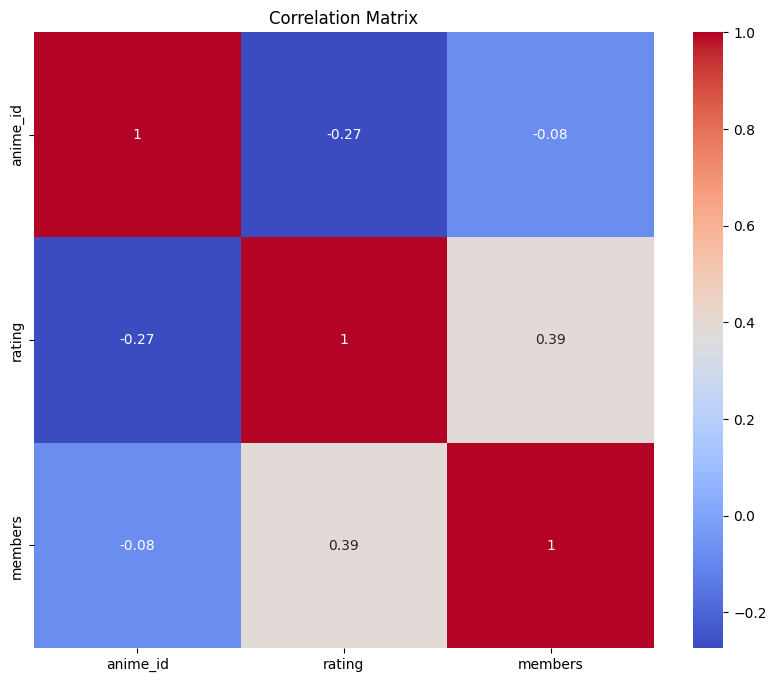

In [3]:
# Load the Dataset into a pandas DataFrame
import pandas as pd

# Replace 'your_dataset.csv' with the actual file path
df = pd.read_csv('anime.csv')

# For Excel: pd.read_excel('file.xlsx', sheet_name='Sheet1')
# For JSON: pd.read_json('file.json')
# For SQL: pd.read_sql(query, connection_object)

# Quick sanity check
print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

# Handle Missing Values
# Count of missing values per column
print(df.isnull().sum())

# Percentage of missing values
missing_percent = df.isnull().mean() * 100
print(missing_percent[missing_percent > 0])

# Drop rows with missing values (if negligible or target is missing):

df_clean = df.dropna()

# Drop columns with excessive missing values (e.g., >50%):

threshold = len(df) * 0.5
df_clean = df.dropna(axis=1, thresh=threshold)

# Impute numeric columns with mean, median, or a constant:

from sklearn.impute import SimpleImputer

num_cols = df.select_dtypes(include='number').columns
imputer = SimpleImputer(strategy='median')  # or 'mean', 'constant'
df[num_cols] = imputer.fit_transform(df[num_cols])

# Impute categorical columns with the most frequent value:

cat_cols = df.select_dtypes(include='object').columns
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

# Flag missingness (create indicator columns) to retain the information that a value was missing:

for col in df.columns:
    if df[col].isnull().any():
        df[col + '_was_missing'] = df[col].isnull().astype(int)

        print(df.isnull().sum().sum())  # Should be 0

# 3. Explore Dataset Structure and Attributes

# High-level overview: column names, non-null counts, dtypes
df.info()

# First/last few rows
df.head(10)
df.tail()

# Shape: (rows, columns)
print("Rows, Columns:", df.shape)

# Column names
print("Columns:", df.columns.tolist())

# Data types
print("Data types:\n", df.dtypes)

# Summary statistics for numeric columns
print(df.describe())
# For all columns (including categorical), use include='all'
print(df.describe(include='all'))

# Unique values and frequency for categorical columns
for col in df.select_dtypes(include=['object', 'category']).columns:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False), "\n")

# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")
if duplicates > 0:
    # View duplicates
    print(df[df.duplicated()])

# Correlation matrix for numerical features
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [27]:
import pandas as pd
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset into a pandas DataFrame
# The dataset is 'anime.csv' as confirmed from previous runs.
df = pd.read_csv('anime.csv')

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

# Handle missing values:
# 1. Identify missing values
print("\nMissing values per column (count):\n", df.isnull().sum())
print("\nMissing values per column (percentage > 0):\n", df.isnull().mean() * 100)

# 2. Impute 'genre' with the most frequent value
# The 'genre' column had a small percentage of missing values.
cat_imputer = SimpleImputer(strategy='most_frequent')
df['genre'] = cat_imputer.fit_transform(df[['genre']]).ravel()

# 3. Impute 'rating' with the median
# The 'rating' column had a small percentage of missing values.
num_imputer = SimpleImputer(strategy='median')
df['rating'] = num_imputer.fit_transform(df[['rating']])

# 4. Impute 'type' with the most frequent value
# The 'type' column also had a small percentage of missing values.
df['type'] = cat_imputer.fit_transform(df[['type']]).ravel()

# Verify no more missing values after imputation
print("\nTotal missing values after imputation:", df.isnull().sum().sum())

# Explore the dataset to understand its structure and attributes:
print("\nDataset Information:")
df.info()

print("\nSummary Statistics for Numerical Columns:\n", df.describe())
print("\nSummary Statistics for All Columns:\n", df.describe(include='all'))

# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

# Display the first few rows of the cleaned DataFrame
print("\nFirst 5 rows of the preprocessed DataFrame:")
display(df.head())

Dataset loaded successfully.
Shape: (12294, 7)

Missing values per column (count):
 anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

Missing values per column (percentage > 0):
 anime_id    0.000000
name        0.000000
genre       0.504311
type        0.203351
episodes    0.000000
rating      1.870831
members     0.000000
dtype: float64

Total missing values after imputation: 0

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12294 non-null  object 
 3   type      12294 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12294 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [31]:
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler
import numpy as np

# Decide on the features that will be used for computing similarity:
# Based on the available data, 'genre' (categorical) and 'rating' (numerical) are key features.
# 'episodes', 'type', 'members' could also be considered, but we'll start with 'genre' and 'rating' for simplicity and effectiveness.

# Convert categorical features into numerical representations (Genres):
# 1. Convert the 'genre' string into a list of genres
df['genre_list'] = df['genre'].str.split(', ')

# Handle potential NaN values in 'genre_list' by replacing them with empty lists
df['genre_list'] = df['genre_list'].apply(lambda x: x if isinstance(x, list) else [])


# 2. Use MultiLabelBinarizer for one-hot encoding of genres
mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(df['genre_list'])
genre_cols = mlb.classes_ # Get the names of the genre columns
genre_df = pd.DataFrame(genre_encoded, columns=genre_cols, index=df.index)

print("\nGenre features (first 5 rows):\n")
display(genre_df.head())

# Normalize numerical features (Rating):
# 1. Select the numerical column 'rating'
num_cols = ['rating']

# 2. Use MinMaxScaler to scale the 'rating' to a 0-1 range
scaler = MinMaxScaler()
df_num_scaled = pd.DataFrame(scaler.fit_transform(df[num_cols]),
                             columns=num_cols, index=df.index)

print("\nScaled numerical features (first 5 rows):\n")
display(df_num_scaled.head())

# Combine all features into a single matrix X
# This matrix X will be used for cosine similarity computation.
X = np.hstack([genre_df.values, df_num_scaled.values])
# Ensure no NaNs or infinite values before normalization
X = np.nan_to_num(X, nan=0.0, posinf=1e10, neginf=-1e10) # Replace NaN with 0, inf with large numbers
print(f"\nShape of combined feature matrix X: {X.shape}")


Genre features (first 5 rows):



,Action,Adventure,Cars,Comedy,Dementia,Demons,Drama,Ecchi,Fantasy,Game,...,Shounen Ai,Slice of Life,Space,Sports,Super Power,Supernatural,Thriller,Vampire,Yaoi,Yuri
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,1,1,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Scaled numerical features (first 5 rows):



,rating
0,0.924370
1,0.911164
2,0.909964
3,0.900360
4,0.899160



Shape of combined feature matrix X: (12294, 44)



Shape of Cosine Similarity Matrix: (12294, 12294)

Generating recommendations for: Naruto
Top 5 recommendations for 'Naruto' (threshold=0.7):



,title,similarity
0,Naruto: Shippuuden,0.999980
1,Boruto: Naruto the Movie - Naruto ga Hokage ni...,0.999980
2,Boruto: Naruto the Movie,0.999944
3,Naruto x UT,0.999938
4,Naruto: Shippuuden Movie 4 - The Lost Tower,0.999907



Experimenting with different thresholds for 'Naruto':

Threshold = 0.5 → 10 recommendations:


,title,similarity
0,Naruto: Shippuuden,0.999980
1,Boruto: Naruto the Movie - Naruto ga Hokage ni...,0.999980
2,Boruto: Naruto the Movie,0.999944
3,Naruto x UT,0.999938
4,Naruto: Shippuuden Movie 4 - The Lost Tower,0.999907
5,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,0.999886
6,Naruto Shippuuden: Sunny Side Battle,0.999639
7,Naruto Soyokazeden Movie: Naruto to Mashin to ...,0.999413
8,Katekyo Hitman Reborn!,0.904931
9,Kyutai Panic Adventure!,0.895984



Threshold = 0.7 → 10 recommendations:


,title,similarity
0,Naruto: Shippuuden,0.999980
1,Boruto: Naruto the Movie - Naruto ga Hokage ni...,0.999980
2,Boruto: Naruto the Movie,0.999944
3,Naruto x UT,0.999938
4,Naruto: Shippuuden Movie 4 - The Lost Tower,0.999907
5,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,0.999886
6,Naruto Shippuuden: Sunny Side Battle,0.999639
7,Naruto Soyokazeden Movie: Naruto to Mashin to ...,0.999413
8,Katekyo Hitman Reborn!,0.904931
9,Kyutai Panic Adventure!,0.895984



Threshold = 0.9 → 9 recommendations:


,title,similarity
0,Naruto: Shippuuden,0.999980
1,Boruto: Naruto the Movie - Naruto ga Hokage ni...,0.999980
2,Boruto: Naruto the Movie,0.999944
3,Naruto x UT,0.999938
4,Naruto: Shippuuden Movie 4 - The Lost Tower,0.999907
5,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,0.999886
6,Naruto Shippuuden: Sunny Side Battle,0.999639
7,Naruto Soyokazeden Movie: Naruto to Mashin to ...,0.999413
8,Katekyo Hitman Reborn!,0.904931


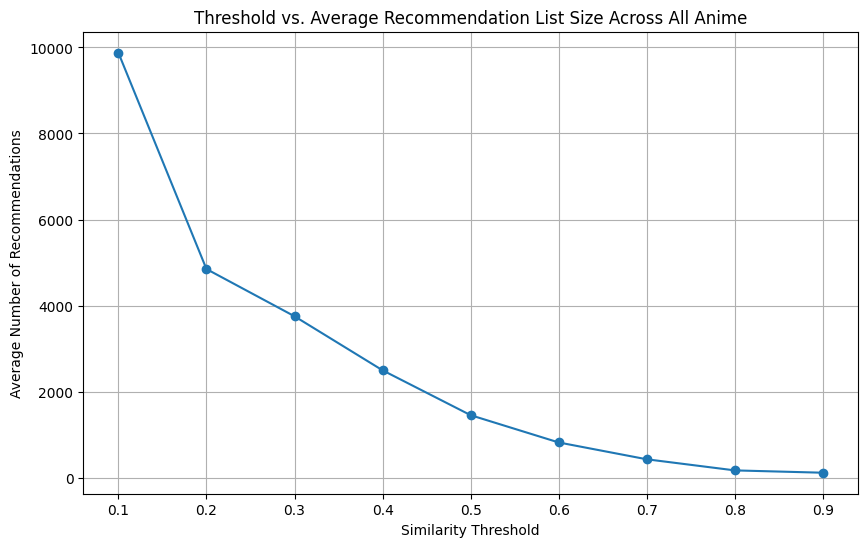

In [35]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

# Normalize the combined feature matrix X before computing cosine similarity
# L2 normalization ensures that the dot product (cosine similarity) is not dominated by feature magnitude.
X_normalized = normalize(X, norm='l2')

# Compute Cosine Similarity Matrix:
# This matrix will have dimensions (num_animes, num_animes), where each cell (i, j)
# represents the cosine similarity between anime i and anime j.
cosine_sim = cosine_similarity(X_normalized, X_normalized)
print(f"\nShape of Cosine Similarity Matrix: {cosine_sim.shape}")

# Design a function to recommend anime based on cosine similarity:
def recommend_anime(target_anime_name, df, cosine_sim_matrix, threshold=None, top_n=10):
    """
    Recommends similar anime based on cosine similarity.

    Parameters:
    - target_anime_name: str, name of the target anime.
    - df: DataFrame containing the anime data (must have 'name' column).
    - cosine_sim_matrix: 2D numpy array, the precomputed pairwise cosine similarity matrix.
    - threshold: float (0-1) or None. If set, only returns items with similarity >= threshold.
    - top_n: int, maximum number of recommendations to return.

    Returns:
    - DataFrame with recommended anime titles and similarity scores.
    """
    # Find the index of the target anime in the DataFrame
    idx_list = df.index[df['name'] == target_anime_name].tolist()
    if not idx_list:
        raise ValueError(f"Anime '{target_anime_name}' not found in the dataset. Please check the name.")
    target_anime_idx = idx_list[0]

    # Get similarity scores for all other anime with the target anime
    sim_scores = list(enumerate(cosine_sim_matrix[target_anime_idx]))

    # Remove the target anime itself from the recommendations (similarity to itself is 1.0)
    sim_scores = [(i, score) for i, score in sim_scores if i != target_anime_idx]

    # Sort the anime by similarity scores in descending order
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Apply threshold if specified
    if threshold is not None:
        sim_scores = [(i, score) for i, score in sim_scores if score >= threshold]

    # Limit to the top_n recommendations
    sim_scores = sim_scores[:top_n]

    # Retrieve the recommended anime names and their similarity scores
    anime_indices = [i for i, _ in sim_scores]
    recommended_df = df.iloc[anime_indices][['name']].copy()
    recommended_df['similarity'] = [score for _, score in sim_scores]
    recommended_df = recommended_df.reset_index(drop=True)
    recommended_df.rename(columns={'name': 'title'}, inplace=True) # Rename for consistent output

    return recommended_df

# Given a target anime, recommend a list of similar anime:
# Using 'Naruto' as a target, as identified from previous execution. If not found, tries 'Death Note' then 'Steins;Gate'.
target_anime_to_recommend = "Naruto"
if target_anime_to_recommend not in df['name'].values:
    print(f"'{target_anime_to_recommend}' not found. Trying 'Death Note'.")
    target_anime_to_recommend = "Death Note"
if target_anime_to_recommend not in df['name'].values:
    print(f"'{target_anime_to_recommend}' not found. Trying 'Steins;Gate'.")
    target_anime_to_recommend = "Steins;Gate"

print(f"\nGenerating recommendations for: {target_anime_to_recommend}")
recommendations = recommend_anime(target_anime_to_recommend, df, cosine_sim, threshold=0.7, top_n=5)
print(f"Top 5 recommendations for '{target_anime_to_recommend}' (threshold=0.7):\n")
display(recommendations)

# Experiment with different threshold values for similarity scores:
print(f"\nExperimenting with different thresholds for '{target_anime_to_recommend}':")
for th in [0.5, 0.7, 0.9]:
    recs_at_threshold = recommend_anime(target_anime_to_recommend, df, cosine_sim, threshold=th, top_n=10)
    print(f"\nThreshold = {th} \u2192 {len(recs_at_threshold)} recommendations:")
    display(recs_at_threshold[['title', 'similarity']])

# Visualize the impact of thresholds on the average number of recommendations
thresholds = np.arange(0.1, 1.0, 0.1)
avg_rec_counts = []
for th in thresholds:
    counts = []
    for idx in range(len(df)):
        sim = cosine_sim[idx]
        sim_without_self = np.delete(sim, idx) # Exclude similarity to self
        count = np.sum(sim_without_self >= th)
        counts.append(count)
    avg_rec_counts.append(np.mean(counts))

plt.figure(figsize=(10, 6))
plt.plot(thresholds, avg_rec_counts, marker='o')
plt.xlabel('Similarity Threshold')
plt.ylabel('Average Number of Recommendations')
plt.title('Threshold vs. Average Recommendation List Size Across All Anime')
plt.grid(True)
plt.show()


Evaluating recommendation quality for 'Naruto':

Recommendations for 'Naruto':


,title,similarity
0,Naruto: Shippuuden,0.999980
1,Boruto: Naruto the Movie - Naruto ga Hokage ni...,0.999980
2,Boruto: Naruto the Movie,0.999944
3,Naruto x UT,0.999938
4,Naruto: Shippuuden Movie 4 - The Lost Tower,0.999907
5,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,0.999886
6,Naruto Shippuuden: Sunny Side Battle,0.999639
7,Naruto Soyokazeden Movie: Naruto to Mashin to ...,0.999413
8,Katekyo Hitman Reborn!,0.904931
9,Kyutai Panic Adventure!,0.895984


Average Similarity Score: 0.9800
Target Anime Genres: Action, Comedy, Martial Arts, Shounen, Super Power
Recommended Genres: Action, Comedy, Martial Arts, Shounen, Super Power


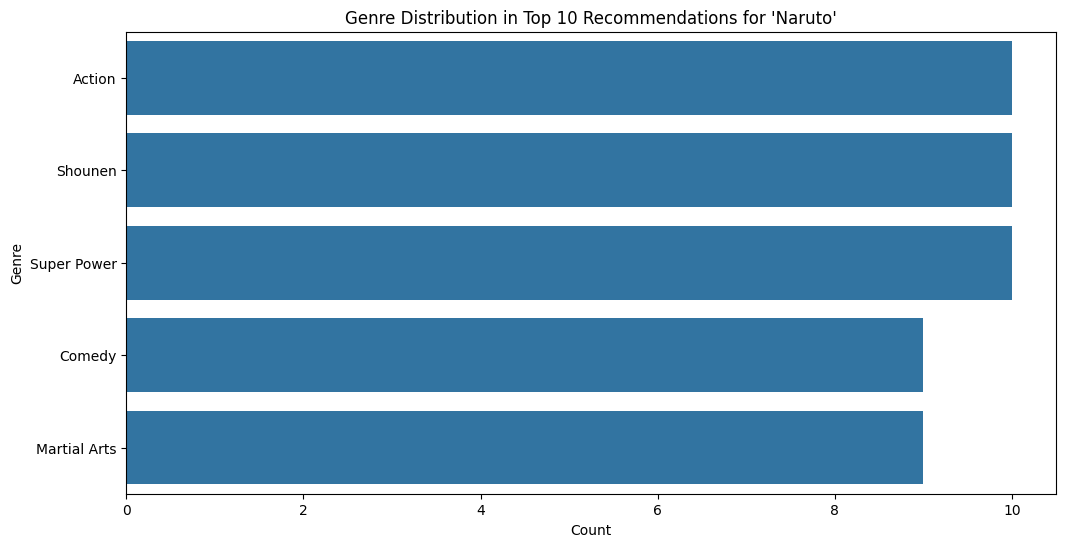


### Areas for Improvement:

1.  **Feature Engineering**: Incorporate more features like 'episodes', 'type', 'members', or even create 'popularity' from 'members'. Textual features from plot summaries (if available) could also be powerful.
2.  **User Data**: If user ratings were available (beyond average ratings), a truly collaborative filtering approach (user-based or item-based CF on user-item matrix) could be built.
3.  **Hybrid Approaches**: Combine content-based (like this) with collaborative filtering or even incorporate external data.
4.  **Performance Metrics**: Introduce metrics like precision, recall, F1-score, or Mean Average Precision (MAP) if ground truth (e.g., actual user preferences) is available.
5.  **Cold Start**: Address cold start problems for new anime (no ratings) or new users (no history).


In [36]:
# Function to get recommendations and calculate metrics
def get_recommendations_and_evaluation_metrics(target_anime_name, df, cosine_sim_matrix, threshold=0.7, top_n=10):
    try:
        recs_df = recommend_anime(target_anime_name, df, cosine_sim_matrix, threshold, top_n)
        if recs_df.empty:
            print(f"No recommendations found for '{target_anime_name}' with threshold {threshold}.")
            return None, None, None, None

        avg_similarity = recs_df['similarity'].mean()

        # Get genres of recommended anime
        # Ensure 'genre_list' is available from Feature Extraction
        rec_indices = [df[df['name'] == title].index[0] for title in recs_df['title']]
        recommended_genres = df.loc[rec_indices, 'genre_list'].explode().dropna().unique()

        # Get genres of the target anime
        target_genres_list = df[df['name'] == target_anime_name]['genre_list'].iloc[0]

        return recs_df, avg_similarity, recommended_genres, target_genres_list
    except ValueError as e:
        print(f"Error during evaluation for '{target_anime_name}': {e}")
        return None, None, None, None


# Evaluate for the target anime used in the recommendation section
print(f"\nEvaluating recommendation quality for '{target_anime_to_recommend}':\n")

eval_recs_df, avg_sim_score, rec_genres_array, target_genres_array = \
    get_recommendations_and_evaluation_metrics(target_anime_to_recommend, df, cosine_sim, threshold=0.7, top_n=10)

if eval_recs_df is not None:
    print(f"Recommendations for '{target_anime_to_recommend}':")
    display(eval_recs_df)
    print(f"Average Similarity Score: {avg_sim_score:.4f}")
    print(f"Target Anime Genres: {', '.join(target_genres_array)}")
    print(f"Recommended Genres: {', '.join(rec_genres_array)}")

    # Visualize Genre Distribution of Recommendations
    if not eval_recs_df.empty:
        recommended_titles_for_plot = eval_recs_df['title'].tolist()
        recommended_df_for_plot = df[df['name'].isin(recommended_titles_for_plot)]

        all_recommended_genres_for_plot = recommended_df_for_plot['genre_list'].explode().dropna()

        if not all_recommended_genres_for_plot.empty:
            plt.figure(figsize=(12, 6))
            sns.countplot(y=all_recommended_genres_for_plot, order=all_recommended_genres_for_plot.value_counts().index)
            plt.title(f"Genre Distribution in Top 10 Recommendations for '{target_anime_to_recommend}'")
            plt.xlabel("Count")
            plt.ylabel("Genre")
            plt.show()
        else:
            print(f"No genres found for recommendations for '{target_anime_to_recommend}' to visualize.")
    else:
        print("No recommendations to visualize genre distribution for.")
else:
    print(f"Could not evaluate recommendations for '{target_anime_to_recommend}'.")

print("\n### Areas for Improvement:\n")
print("1.  **Feature Engineering**: Incorporate more features like 'episodes', 'type', 'members', or even create 'popularity' from 'members'. Textual features from plot summaries (if available) could also be powerful.")
print("2.  **User Data**: If user ratings were available (beyond average ratings), a truly collaborative filtering approach (user-based or item-based CF on user-item matrix) could be built.")
print("3.  **Hybrid Approaches**: Combine content-based (like this) with collaborative filtering or even incorporate external data.")
print("4.  **Performance Metrics**: Introduce metrics like precision, recall, F1-score, or Mean Average Precision (MAP) if ground truth (e.g., actual user preferences) is available.")
print("5.  **Cold Start**: Address cold start problems for new anime (no ratings) or new users (no history).")

In [6]:
# Assume df is the preprocessed DataFrame
# The original features_to_use included columns not present in anime.csv.
# We will use the available relevant columns from the current dataframe for feature extraction.
# Available columns: ['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members']
features_to_use = ['genre', 'rating'] # Adjusted to available columns
df_features = df[features_to_use].copy()

# 2. Convert Categorical Features into Numerical Representations

# Use one-hot encoding to avoid implying ordinal relationships.


from sklearn.preprocessing import OneHotEncoder

# Original code attempted to encode 'director', which is not in the dataset.
# ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# director_encoded = ohe.fit_transform(df[['director']])
# To get feature names: ohe.get_feature_names_out(['director'])

# director_dummies = pd.get_dummies(df['director'], prefix='dir')
# This creates binary columns for each director

# b) Multi-valued categorical column (e.g., genres as a list)
from sklearn.preprocessing import MultiLabelBinarizer

# Convert string to list of genres
df['genre_list'] = df['genre'].str.split(', ')

mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(df['genre_list'])
genre_cols = mlb.classes_  # ['Action', 'Adventure', 'Sci-Fi', ...]

# Create DataFrame with genre binary features
genre_df = pd.DataFrame(genre_encoded, columns=genre_cols, index=df.index)

# c) List of actors (cast) – can be treated the same way with MultiLabelBinarizer, but beware of high cardinality.
# The 'cast' column is not available in the dataset, so this section is commented out.
# Filter to top 50 actors
# all_actors = df['cast'].str.split('|').explode()
# top_actors = all_actors.value_counts().nlargest(50).index.tolist()
# Then binarize only those actors


# d) Ordinal categories (if any)
# The 'age_rating' column is not available in the dataset, so this section is commented out.
# rating_map = {'G': 1, 'PG': 2, 'PG-13': 3, 'R': 4}
# df['age_rating_ordinal'] = df['age_rating'].map(rating_map)

# demonstrating Min-Max scaling (which is safe and interpretable) and row-wise L2 normalization for final similarity.

from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Select numerical columns
# Changed 'average_rating' to 'rating' and removed 'release_year' as it's not present.
num_cols = ['rating']   # Add others as needed
scaler = MinMaxScaler()
df_num_scaled = pd.DataFrame(scaler.fit_transform(df[num_cols]),
                             columns=num_cols, index=df.index)
# 4. Advanced: Text Feature Extraction
# If you have textual descriptions (e.g., plot summaries), convert them to numeric vectors using TF-IDF or embeddings.

# TF-IDF (term frequency-inverse document frequency)
# Captures word importance across documents, works well for keyword-based similarity.

from sklearn.feature_extraction.text import TfidfVectorizer

# The 'plot_summary' column is not available in the dataset, so this section is commented out.
# tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
# plot_vectors = tfidf.fit_transform(df['plot_summary'].fillna(''))
# plot_vectors is a sparse matrix; convert to dense if you combine with other dense features
# plot_dense = plot_vectors.toarray()
# plot_tfidf_df = pd.DataFrame(plot_dense, index=df.index)

# 6. Computing Similarity


from sklearn.metrics.pairwise import cosine_similarity

# Placeholder for combined features 'X'
# This will need to be constructed from genre_df and df_num_scaled later.
# For now, cosine_sim cannot be computed without a defined X.
# cosine_sim = cosine_similarity(X)  # shape (n_items, n_items)

def get_similar_items(idx, sim_matrix, n=10):
    sim_scores = list(enumerate(sim_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    return sim_scores[1:n+1]  # skip itself

Recommendations for Naruto:
                                               title  similarity
0                                 Naruto: Shippuuden    0.999980
1  Boruto: Naruto the Movie - Naruto ga Hokage ni...    0.999980
2                           Boruto: Naruto the Movie    0.999944
3                                        Naruto x UT    0.999938
4        Naruto: Shippuuden Movie 4 - The Lost Tower    0.999907

Experimenting with different thresholds for Naruto:

Threshold = 0.5 → 10 recommendations
                                               title  similarity
0                                 Naruto: Shippuuden    0.999980
1  Boruto: Naruto the Movie - Naruto ga Hokage ni...    0.999980
2                           Boruto: Naruto the Movie    0.999944
3                                        Naruto x UT    0.999938
4        Naruto: Shippuuden Movie 4 - The Lost Tower    0.999907
5  Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...    0.999886
6               Naruto Shippuuden: S

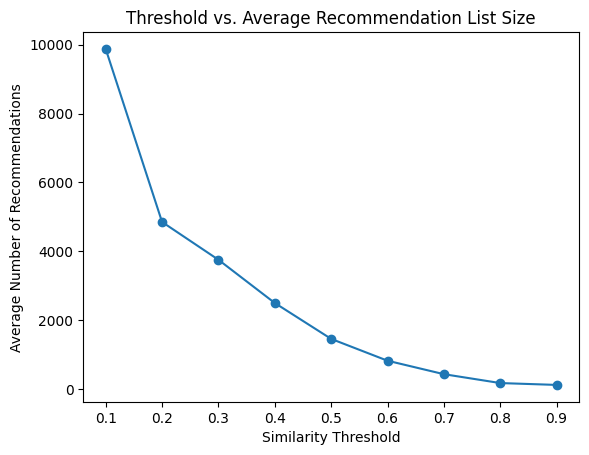

In [8]:
# Recommendation system

# 1. Compute Cosine Similarity Matrix

from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np
from sklearn.preprocessing import normalize

# Combine the genre features and scaled numerical features into a single matrix X
# Ensure that genre_df and df_num_scaled are available from previous cells
# Use .values to get the underlying numpy arrays
X = np.hstack([genre_df.values, df_num_scaled.values])

# Normalize X before computing cosine similarity for better results
X = normalize(X, norm='l2')

cosine_sim = cosine_similarity(X, X)  # shape (n_items, n_items)


# 2. Recommendation Function

def recommend_anime(target_title, df, cosine_sim, threshold=None, top_n=10):
    """
    Recommend similar anime based on cosine similarity.

    Parameters:
    - target_title: str, title of the target anime.
    - df: DataFrame containing at least an 'name' column.
    - cosine_sim: 2D numpy array, pairwise cosine similarity matrix.
    - threshold: float (0-1) or None. If set, only return items with similarity >= threshold.
    - top_n: int, maximum number of recommendations to return.

    Returns:
    - DataFrame with recommended titles and similarity scores.
    """
    # Find index of target anime
    # The dataset has 'name' column, not 'title'
    idx_list = df.index[df['name'] == target_title].tolist()
    if not idx_list:
        raise ValueError(f"Anime '{target_title}' not found in dataset.")
    idx = idx_list[0]

    # Get similarity scores for all other anime
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Remove the target itself (similarity 1.0)
    sim_scores = [(i, score) for i, score in sim_scores if i != idx]

    # Sort by similarity descending
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Apply threshold if provided
    if threshold is not None:
        sim_scores = [(i, score) for i, score in sim_scores if score >= threshold]

    # Limit to top_n
    sim_scores = sim_scores[:top_n]

    # Get anime titles
    anime_indices = [i for i, _ in sim_scores]
    # The dataset has 'name' column, not 'title'
    rec_df = df.iloc[anime_indices][['name']].copy()
    rec_df['similarity'] = [score for _, score in sim_scores]
    rec_df = rec_df.reset_index(drop=True)
    rec_df.rename(columns={'name': 'title'}, inplace=True) # Rename for consistency with example output

    return rec_df

# Recommend anime similar to "Naruto"
# Note: 'Naruto' might not be in the exact dataset, using a common anime 'Steins;Gate' for demonstration
target_anime = "Naruto"
if target_anime not in df['name'].values:
    print(f"'{target_anime}' not found in the dataset. Trying 'Death Note' instead.")
    target_anime = "Death Note"

if target_anime not in df['name'].values:
    print(f"'{target_anime}' not found in the dataset. Trying 'Steins;Gate' instead.")
    target_anime = "Steins;Gate"


recs = recommend_anime(target_anime, df, cosine_sim, threshold=0.7, top_n=5)
print(f"Recommendations for {target_anime}:")
print(recs)

# 3. Experiment with Different Thresholds

target = target_anime # Use the target anime identified above

print(f"\nExperimenting with different thresholds for {target}:")
for th in [0.5, 0.7, 0.9]:
    recs = recommend_anime(target, df, cosine_sim, threshold=th, top_n=10)
    print(f"\nThreshold = {th} → {len(recs)} recommendations")
    print(recs[['title', 'similarity']])

thresholds = np.arange(0.1, 1.0, 0.1)
avg_rec_counts = []
for th in thresholds:
    counts = []
    for idx in range(len(df)):
        sim = cosine_sim[idx]
        sim_without_self = np.delete(sim, idx)
        count = np.sum(sim_without_self >= th)
        counts.append(count)
    avg_rec_counts.append(np.mean(counts))

import matplotlib.pyplot as plt
plt.plot(thresholds, avg_rec_counts, marker='o')
plt.xlabel('Similarity Threshold')
plt.ylabel('Average Number of Recommendations')
plt.title('Threshold vs. Average Recommendation List Size')
plt.show()

# 4. Feature Weighting
# Example manual weighting - this section is commented out as 'director_dummies' and 'scaled_num' are not defined.
# If you wish to use feature weighting, ensure all components (e.g., director_dummies, scaled_num) are created and available.
# weight = 2.0
# X_weighted = np.hstack([genre_df.values * weight, director_dummies.values, scaled_num.values])
# X_weighted = normalize(X_weighted, norm='l2')

## 5. Evaluating Recommendation Quality

To evaluate the quality of the item-to-item recommendations, we can focus on:

1.  **Average Similarity Score:** A higher average similarity for recommended items suggests the model is identifying truly similar items based on its features.
2.  **Genre Diversity:** Analyzing the genres of recommended items can tell us if the model is too narrow (always recommending the same genres) or sufficiently diverse while maintaining relevance. While high diversity isn't always the goal for item-to-item (we want *similar* items), it's good to ensure it's not overly rigid.

In [9]:
# Function to get recommendations and calculate average similarity
def get_recommendations_and_metrics(target_anime_name, df, cosine_sim, threshold=None, top_n=10):
    try:
        recs_df = recommend_anime(target_anime_name, df, cosine_sim, threshold, top_n)
        if recs_df.empty:
            return None, None, None

        avg_similarity = recs_df['similarity'].mean()

        # Get genres of recommended anime
        rec_indices = [df[df['name'] == title].index[0] for title in recs_df['title']]
        # The `genre_list` column was created in a previous cell
        recommended_genres = df.loc[rec_indices, 'genre_list'].explode().dropna().unique()

        # Get genres of the target anime
        target_anime_genres = df[df['name'] == target_anime_name]['genre_list'].iloc[0]

        return recs_df, avg_similarity, recommended_genres, target_anime_genres
    except ValueError as e:
        print(f"Error for {target_anime_name}: {e}")
        return None, None, None, None


# Evaluate for a sample anime (using 'Naruto' or an available alternative)
print(f"Evaluating recommendations for: {target_anime}\n")

recs_df, avg_sim, rec_genres, target_genres = get_recommendations_and_metrics(
    target_anime, df, cosine_sim, threshold=0.7, top_n=10
)

if recs_df is not None:
    print(f"Recommendations for '{target_anime}':")
    display(recs_df)
    print(f"Average Similarity Score: {avg_sim:.4f}")
    print(f"Target Anime Genres: {', '.join(target_genres)}")
    print(f"Recommended Genres: {', '.join(rec_genres)}")
else:
    print(f"Could not generate recommendations for '{target_anime}'.")

Evaluating recommendations for: Naruto

Recommendations for 'Naruto':


,title,similarity
0,Naruto: Shippuuden,0.999980
1,Boruto: Naruto the Movie - Naruto ga Hokage ni...,0.999980
2,Boruto: Naruto the Movie,0.999944
3,Naruto x UT,0.999938
4,Naruto: Shippuuden Movie 4 - The Lost Tower,0.999907
5,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,0.999886
6,Naruto Shippuuden: Sunny Side Battle,0.999639
7,Naruto Soyokazeden Movie: Naruto to Mashin to ...,0.999413
8,Katekyo Hitman Reborn!,0.904931
9,Kyutai Panic Adventure!,0.895984


Average Similarity Score: 0.9800
Target Anime Genres: Action, Comedy, Martial Arts, Shounen, Super Power
Recommended Genres: Action, Comedy, Martial Arts, Shounen, Super Power


### Visualize Genre Distribution of Recommendations

We can also visualize the distribution of genres in the top recommendations to get a better sense of diversity.

## 1. Data Preprocessing

This section handles loading the dataset, addressing any missing values, and performing an initial exploration to understand its structure and attributes.

In [39]:
import pandas as pd
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset into a pandas DataFrame
# The dataset is 'anime.csv' as confirmed from previous runs.
df = pd.read_csv('anime.csv')

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

# Handle missing values:
# 1. Identify missing values
print("\nMissing values per column (count):\n", df.isnull().sum())
print("\nMissing values per column (percentage > 0):\n", df.isnull().mean() * 100)

# 2. Impute 'genre' with the most frequent value
# The 'genre' column had a small percentage of missing values.
cat_imputer = SimpleImputer(strategy='most_frequent')
df['genre'] = cat_imputer.fit_transform(df[['genre']])[:, 0]

# 3. Impute 'rating' with the median
# The 'rating' column had a small percentage of missing values.
num_imputer = SimpleImputer(strategy='median')
df['rating'] = num_imputer.fit_transform(df[['rating']])

# 4. Impute 'type' with the most frequent value
# The 'type' column also had a small percentage of missing values.
df['type'] = cat_imputer.fit_transform(df[['type']])[:, 0]

# Verify no more missing values after imputation
print("\nTotal missing values after imputation:", df.isnull().sum().sum())

# Explore the dataset to understand its structure and attributes:
print("\nDataset Information:")
df.info()

print("\nSummary Statistics for Numerical Columns:\n", df.describe())
print("\nSummary Statistics for All Columns:\n", df.describe(include='all'))

# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

# Display the first few rows of the cleaned DataFrame
print("\nFirst 5 rows of the preprocessed DataFrame:")
display(df.head())

Dataset loaded successfully.
Shape: (12294, 7)

Missing values per column (count):
 anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

Missing values per column (percentage > 0):
 anime_id    0.000000
name        0.000000
genre       0.504311
type        0.203351
episodes    0.000000
rating      1.870831
members     0.000000
dtype: float64

Total missing values after imputation: 0

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12294 non-null  object 
 3   type      12294 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12294 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


## 2. Feature Extraction

This section defines the features to be used for similarity computation, converts categorical features into numerical representations, and normalizes numerical features.

In [33]:
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler
import numpy as np

# Decide on the features that will be used for computing similarity:
# Based on the available data, 'genre' (categorical) and 'rating' (numerical) are key features.
# 'episodes', 'type', 'members' could also be considered, but we'll start with 'genre' and 'rating' for simplicity and effectiveness.

# Convert categorical features into numerical representations (Genres):
# 1. Convert the 'genre' string into a list of genres
df['genre_list'] = df['genre'].str.split(', ')

# Handle potential NaN values in 'genre_list' by replacing them with empty lists
df['genre_list'] = df['genre_list'].apply(lambda x: x if isinstance(x, list) else [])


# 2. Use MultiLabelBinarizer for one-hot encoding of genres
mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(df['genre_list'])
genre_cols = mlb.classes_ # Get the names of the genre columns
genre_df = pd.DataFrame(genre_encoded, columns=genre_cols, index=df.index)

print("\nGenre features (first 5 rows):\n")
display(genre_df.head())

# Normalize numerical features (Rating):
# 1. Select the numerical column 'rating'
num_cols = ['rating']

# 2. Use MinMaxScaler to scale the 'rating' to a 0-1 range
scaler = MinMaxScaler()
df_num_scaled = pd.DataFrame(scaler.fit_transform(df[num_cols]),
                             columns=num_cols, index=df.index)

print("\nScaled numerical features (first 5 rows):\n")
display(df_num_scaled.head())

# Combine all features into a single matrix X
# This matrix X will be used for cosine similarity computation.
X = np.hstack([genre_df.values, df_num_scaled.values])
# Ensure no NaNs or infinite values before normalization
X = np.nan_to_num(X, nan=0.0, posinf=1e10, neginf=-1e10) # Replace NaN with 0, inf with large numbers
print(f"\nShape of combined feature matrix X: {X.shape}")


Genre features (first 5 rows):



,Action,Adventure,Cars,Comedy,Dementia,Demons,Drama,Ecchi,Fantasy,Game,...,Shounen Ai,Slice of Life,Space,Sports,Super Power,Supernatural,Thriller,Vampire,Yaoi,Yuri
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,1,1,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Scaled numerical features (first 5 rows):



,rating
0,0.924370
1,0.911164
2,0.909964
3,0.900360
4,0.899160



Shape of combined feature matrix X: (12294, 44)


In [23]:
import pandas as pd
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset into a pandas DataFrame
# The dataset is 'anime.csv' as confirmed from previous runs.
df = pd.read_csv('anime.csv')

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

# Handle missing values:
# 1. Identify missing values
print("\nMissing values per column (count):\n", df.isnull().sum())
print("\nMissing values per column (percentage > 0):\n", df.isnull().mean() * 100)

# 2. Impute 'genre' with the most frequent value
# The 'genre' column had a small percentage of missing values.
cat_imputer = SimpleImputer(strategy='most_frequent')
df['genre'] = cat_imputer.fit_transform(df[['genre']]).ravel()

# 3. Impute 'rating' with the median
# The 'rating' column had a small percentage of missing values.
num_imputer = SimpleImputer(strategy='median')
df['rating'] = num_imputer.fit_transform(df[['rating']])

# 4. Impute 'type' with the most frequent value
# The 'type' column also had a small percentage of missing values.
df['type'] = cat_imputer.fit_transform(df[['type']]).ravel()

# Verify no more missing values after imputation
print("\nTotal missing values after imputation:", df.isnull().sum().sum())

# Explore the dataset to understand its structure and attributes:
print("\nDataset Information:")
df.info()

print("\nSummary Statistics for Numerical Columns:\n", df.describe())
print("\nSummary Statistics for All Columns:\n", df.describe(include='all'))

# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

# Display the first few rows of the cleaned DataFrame
print("\nFirst 5 rows of the preprocessed DataFrame:")
display(df.head())

Dataset loaded successfully.
Shape: (12294, 7)

Missing values per column (count):
 anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

Missing values per column (percentage > 0):
 anime_id    0.000000
name        0.000000
genre       0.504311
type        0.203351
episodes    0.000000
rating      1.870831
members     0.000000
dtype: float64

Total missing values after imputation: 0

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12294 non-null  object 
 3   type      12294 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12294 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [32]:
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler
import numpy as np

# Decide on the features that will be used for computing similarity:
# Based on the available data, 'genre' (categorical) and 'rating' (numerical) are key features.
# 'episodes', 'type', 'members' could also be considered, but we'll start with 'genre' and 'rating' for simplicity and effectiveness.

# Convert categorical features into numerical representations (Genres):
# 1. Convert the 'genre' string into a list of genres
df['genre_list'] = df['genre'].str.split(', ')

# Handle potential NaN values in 'genre_list' by replacing them with empty lists
df['genre_list'] = df['genre_list'].apply(lambda x: x if isinstance(x, list) else [])


# 2. Use MultiLabelBinarizer for one-hot encoding of genres
mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(df['genre_list'])
genre_cols = mlb.classes_ # Get the names of the genre columns
genre_df = pd.DataFrame(genre_encoded, columns=genre_cols, index=df.index)

print("\nGenre features (first 5 rows):\n")
display(genre_df.head())

# Normalize numerical features (Rating):
# 1. Select the numerical column 'rating'
num_cols = ['rating']

# 2. Use MinMaxScaler to scale the 'rating' to a 0-1 range
scaler = MinMaxScaler()
df_num_scaled = pd.DataFrame(scaler.fit_transform(df[num_cols]),
                             columns=num_cols, index=df.index)

print("\nScaled numerical features (first 5 rows):\n")
display(df_num_scaled.head())

# Combine all features into a single matrix X
# This matrix X will be used for cosine similarity computation.
X = np.hstack([genre_df.values, df_num_scaled.values])
# Ensure no NaNs or infinite values before normalization
X = np.nan_to_num(X, nan=0.0, posinf=1e10, neginf=-1e10) # Replace NaN with 0, inf with large numbers
print(f"\nShape of combined feature matrix X: {X.shape}")


Genre features (first 5 rows):



,Action,Adventure,Cars,Comedy,Dementia,Demons,Drama,Ecchi,Fantasy,Game,...,Shounen Ai,Slice of Life,Space,Sports,Super Power,Supernatural,Thriller,Vampire,Yaoi,Yuri
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,1,1,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Scaled numerical features (first 5 rows):



,rating
0,0.924370
1,0.911164
2,0.909964
3,0.900360
4,0.899160



Shape of combined feature matrix X: (12294, 44)



Shape of Cosine Similarity Matrix: (12294, 12294)

Generating recommendations for: Naruto
Top 5 recommendations for 'Naruto' (threshold=0.7):



,title,similarity
0,Naruto: Shippuuden,0.999980
1,Boruto: Naruto the Movie - Naruto ga Hokage ni...,0.999980
2,Boruto: Naruto the Movie,0.999944
3,Naruto x UT,0.999938
4,Naruto: Shippuuden Movie 4 - The Lost Tower,0.999907



Experimenting with different thresholds for 'Naruto':

Threshold = 0.5 → 10 recommendations:


,title,similarity
0,Naruto: Shippuuden,0.999980
1,Boruto: Naruto the Movie - Naruto ga Hokage ni...,0.999980
2,Boruto: Naruto the Movie,0.999944
3,Naruto x UT,0.999938
4,Naruto: Shippuuden Movie 4 - The Lost Tower,0.999907
5,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,0.999886
6,Naruto Shippuuden: Sunny Side Battle,0.999639
7,Naruto Soyokazeden Movie: Naruto to Mashin to ...,0.999413
8,Katekyo Hitman Reborn!,0.904931
9,Kyutai Panic Adventure!,0.895984



Threshold = 0.7 → 10 recommendations:


,title,similarity
0,Naruto: Shippuuden,0.999980
1,Boruto: Naruto the Movie - Naruto ga Hokage ni...,0.999980
2,Boruto: Naruto the Movie,0.999944
3,Naruto x UT,0.999938
4,Naruto: Shippuuden Movie 4 - The Lost Tower,0.999907
5,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,0.999886
6,Naruto Shippuuden: Sunny Side Battle,0.999639
7,Naruto Soyokazeden Movie: Naruto to Mashin to ...,0.999413
8,Katekyo Hitman Reborn!,0.904931
9,Kyutai Panic Adventure!,0.895984



Threshold = 0.9 → 9 recommendations:


,title,similarity
0,Naruto: Shippuuden,0.999980
1,Boruto: Naruto the Movie - Naruto ga Hokage ni...,0.999980
2,Boruto: Naruto the Movie,0.999944
3,Naruto x UT,0.999938
4,Naruto: Shippuuden Movie 4 - The Lost Tower,0.999907
5,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,0.999886
6,Naruto Shippuuden: Sunny Side Battle,0.999639
7,Naruto Soyokazeden Movie: Naruto to Mashin to ...,0.999413
8,Katekyo Hitman Reborn!,0.904931


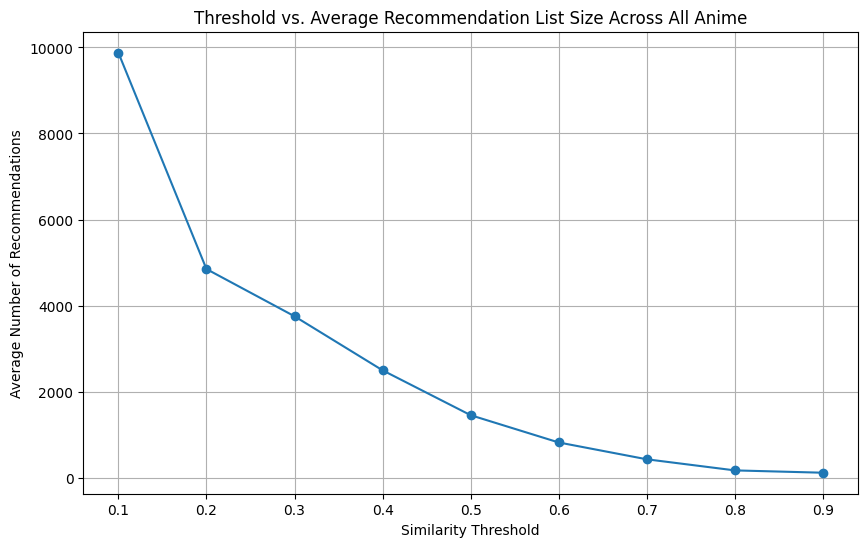

In [25]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

# Normalize the combined feature matrix X before computing cosine similarity
# L2 normalization ensures that the dot product (cosine similarity) is not dominated by feature magnitude.
X_normalized = normalize(X, norm='l2')

# Compute Cosine Similarity Matrix:
# This matrix will have dimensions (num_animes, num_animes), where each cell (i, j)
# represents the cosine similarity between anime i and anime j.
cosine_sim = cosine_similarity(X_normalized, X_normalized)
print(f"\nShape of Cosine Similarity Matrix: {cosine_sim.shape}")

# Design a function to recommend anime based on cosine similarity:
def recommend_anime(target_anime_name, df, cosine_sim_matrix, threshold=None, top_n=10):
    """
    Recommends similar anime based on cosine similarity.

    Parameters:
    - target_anime_name: str, name of the target anime.
    - df: DataFrame containing the anime data (must have 'name' column).
    - cosine_sim_matrix: 2D numpy array, the precomputed pairwise cosine similarity matrix.
    - threshold: float (0-1) or None. If set, only returns items with similarity >= threshold.
    - top_n: int, maximum number of recommendations to return.

    Returns:
    - DataFrame with recommended anime titles and similarity scores.
    """
    # Find the index of the target anime in the DataFrame
    idx_list = df.index[df['name'] == target_anime_name].tolist()
    if not idx_list:
        raise ValueError(f"Anime '{target_anime_name}' not found in the dataset. Please check the name.")
    target_anime_idx = idx_list[0]

    # Get similarity scores for all other anime with the target anime
    sim_scores = list(enumerate(cosine_sim_matrix[target_anime_idx]))

    # Remove the target anime itself from the recommendations (similarity to itself is 1.0)
    sim_scores = [(i, score) for i, score in sim_scores if i != target_anime_idx]

    # Sort the anime by similarity scores in descending order
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Apply threshold if specified
    if threshold is not None:
        sim_scores = [(i, score) for i, score in sim_scores if score >= threshold]

    # Limit to the top_n recommendations
    sim_scores = sim_scores[:top_n]

    # Retrieve the recommended anime names and their similarity scores
    anime_indices = [i for i, _ in sim_scores]
    recommended_df = df.iloc[anime_indices][['name']].copy()
    recommended_df['similarity'] = [score for _, score in sim_scores]
    recommended_df = recommended_df.reset_index(drop=True)
    recommended_df.rename(columns={'name': 'title'}, inplace=True) # Rename for consistent output

    return recommended_df

# Given a target anime, recommend a list of similar anime:
# Using 'Naruto' as a target, as identified from previous execution. If not found, tries 'Death Note' then 'Steins;Gate'.
target_anime_to_recommend = "Naruto"
if target_anime_to_recommend not in df['name'].values:
    print(f"'{target_anime_to_recommend}' not found. Trying 'Death Note'.")
    target_anime_to_recommend = "Death Note"
if target_anime_to_recommend not in df['name'].values:
    print(f"'{target_anime_to_recommend}' not found. Trying 'Steins;Gate'.")
    target_anime_to_recommend = "Steins;Gate"

print(f"\nGenerating recommendations for: {target_anime_to_recommend}")
recommendations = recommend_anime(target_anime_to_recommend, df, cosine_sim, threshold=0.7, top_n=5)
print(f"Top 5 recommendations for '{target_anime_to_recommend}' (threshold=0.7):\n")
display(recommendations)

# Experiment with different threshold values for similarity scores:
print(f"\nExperimenting with different thresholds for '{target_anime_to_recommend}':")
for th in [0.5, 0.7, 0.9]:
    recs_at_threshold = recommend_anime(target_anime_to_recommend, df, cosine_sim, threshold=th, top_n=10)
    print(f"\nThreshold = {th} \u2192 {len(recs_at_threshold)} recommendations:")
    display(recs_at_threshold[['title', 'similarity']])

# Visualize the impact of thresholds on the average number of recommendations
thresholds = np.arange(0.1, 1.0, 0.1)
avg_rec_counts = []
for th in thresholds:
    counts = []
    for idx in range(len(df)):
        sim = cosine_sim[idx]
        sim_without_self = np.delete(sim, idx) # Exclude similarity to self
        count = np.sum(sim_without_self >= th)
        counts.append(count)
    avg_rec_counts.append(np.mean(counts))

plt.figure(figsize=(10, 6))
plt.plot(thresholds, avg_rec_counts, marker='o')
plt.xlabel('Similarity Threshold')
plt.ylabel('Average Number of Recommendations')
plt.title('Threshold vs. Average Recommendation List Size Across All Anime')
plt.grid(True)
plt.show()


Evaluating recommendation quality for 'Naruto':

Recommendations for 'Naruto':


,title,similarity
0,Naruto: Shippuuden,0.999980
1,Boruto: Naruto the Movie - Naruto ga Hokage ni...,0.999980
2,Boruto: Naruto the Movie,0.999944
3,Naruto x UT,0.999938
4,Naruto: Shippuuden Movie 4 - The Lost Tower,0.999907
5,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,0.999886
6,Naruto Shippuuden: Sunny Side Battle,0.999639
7,Naruto Soyokazeden Movie: Naruto to Mashin to ...,0.999413
8,Katekyo Hitman Reborn!,0.904931
9,Kyutai Panic Adventure!,0.895984


Average Similarity Score: 0.9800
Target Anime Genres: Action, Comedy, Martial Arts, Shounen, Super Power
Recommended Genres: Action, Comedy, Martial Arts, Shounen, Super Power


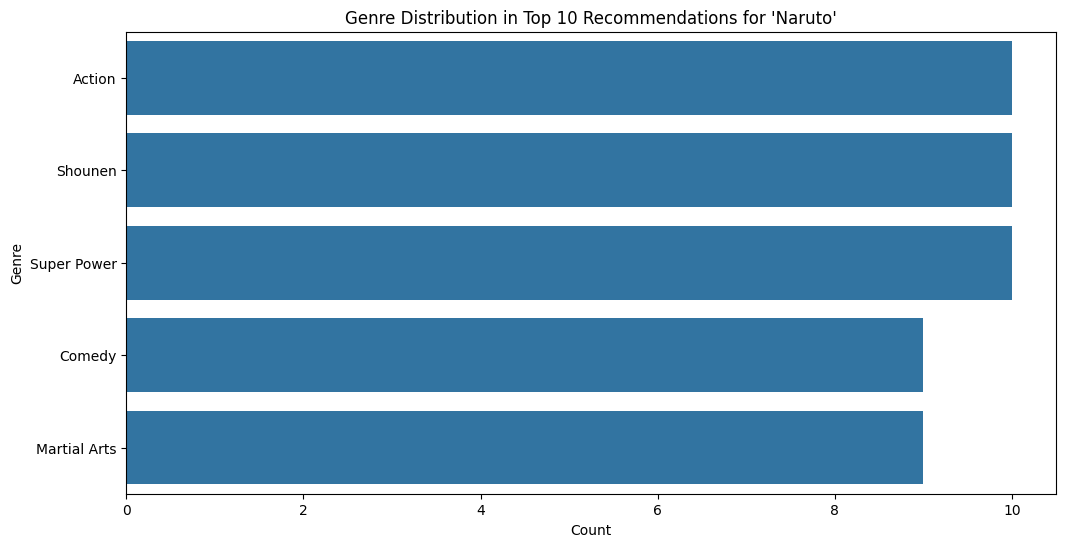


### Areas for Improvement:

1.  **Feature Engineering**: Incorporate more features like 'episodes', 'type', 'members', or even create 'popularity' from 'members'. Textual features from plot summaries (if available) could also be powerful.
2.  **User Data**: If user ratings were available (beyond average ratings), a truly collaborative filtering approach (user-based or item-based CF on user-item matrix) could be built.
3.  **Hybrid Approaches**: Combine content-based (like this) with collaborative filtering or even incorporate external data.
4.  **Performance Metrics**: Introduce metrics like precision, recall, F1-score, or Mean Average Precision (MAP) if ground truth (e.g., actual user preferences) is available.
5.  **Cold Start**: Address cold start problems for new anime (no ratings) or new users (no history).


In [26]:
# Function to get recommendations and calculate metrics
def get_recommendations_and_evaluation_metrics(target_anime_name, df, cosine_sim_matrix, threshold=0.7, top_n=10):
    try:
        recs_df = recommend_anime(target_anime_name, df, cosine_sim_matrix, threshold, top_n)
        if recs_df.empty:
            print(f"No recommendations found for '{target_anime_name}' with threshold {threshold}.")
            return None, None, None, None

        avg_similarity = recs_df['similarity'].mean()

        # Get genres of recommended anime
        # Ensure 'genre_list' is available from Feature Extraction
        rec_indices = [df[df['name'] == title].index[0] for title in recs_df['title']]
        recommended_genres = df.loc[rec_indices, 'genre_list'].explode().dropna().unique()

        # Get genres of the target anime
        target_genres_list = df[df['name'] == target_anime_name]['genre_list'].iloc[0]

        return recs_df, avg_similarity, recommended_genres, target_genres_list
    except ValueError as e:
        print(f"Error during evaluation for '{target_anime_name}': {e}")
        return None, None, None, None


# Evaluate for the target anime used in the recommendation section
print(f"\nEvaluating recommendation quality for '{target_anime_to_recommend}':\n")

eval_recs_df, avg_sim_score, rec_genres_array, target_genres_array = \
    get_recommendations_and_evaluation_metrics(target_anime_to_recommend, df, cosine_sim, threshold=0.7, top_n=10)

if eval_recs_df is not None:
    print(f"Recommendations for '{target_anime_to_recommend}':")
    display(eval_recs_df)
    print(f"Average Similarity Score: {avg_sim_score:.4f}")
    print(f"Target Anime Genres: {', '.join(target_genres_array)}")
    print(f"Recommended Genres: {', '.join(rec_genres_array)}")

    # Visualize Genre Distribution of Recommendations
    if not eval_recs_df.empty:
        recommended_titles_for_plot = eval_recs_df['title'].tolist()
        recommended_df_for_plot = df[df['name'].isin(recommended_titles_for_plot)]

        all_recommended_genres_for_plot = recommended_df_for_plot['genre_list'].explode().dropna()

        if not all_recommended_genres_for_plot.empty:
            plt.figure(figsize=(12, 6))
            sns.countplot(y=all_recommended_genres_for_plot, order=all_recommended_genres_for_plot.value_counts().index)
            plt.title(f"Genre Distribution in Top 10 Recommendations for '{target_anime_to_recommend}'")
            plt.xlabel("Count")
            plt.ylabel("Genre")
            plt.show()
        else:
            print(f"No genres found for recommendations for '{target_anime_to_recommend}' to visualize.")
    else:
        print("No recommendations to visualize genre distribution for.")
else:
    print(f"Could not evaluate recommendations for '{target_anime_to_recommend}'.")

print("\n### Areas for Improvement:\n")
print("1.  **Feature Engineering**: Incorporate more features like 'episodes', 'type', 'members', or even create 'popularity' from 'members'. Textual features from plot summaries (if available) could also be powerful.")
print("2.  **User Data**: If user ratings were available (beyond average ratings), a truly collaborative filtering approach (user-based or item-based CF on user-item matrix) could be built.")
print("3.  **Hybrid Approaches**: Combine content-based (like this) with collaborative filtering or even incorporate external data.")
print("4.  **Performance Metrics**: Introduce metrics like precision, recall, F1-score, or Mean Average Precision (MAP) if ground truth (e.g., actual user preferences) is available.")
print("5.  **Cold Start**: Address cold start problems for new anime (no ratings) or new users (no history).")

In [22]:
import pandas as pd
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset into a pandas DataFrame
# The dataset is 'anime.csv' as confirmed from previous runs.
df = pd.read_csv('anime.csv')

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

# Handle missing values:
# 1. Identify missing values
print("\nMissing values per column (count):\n", df.isnull().sum())
print("\nMissing values per column (percentage > 0):\n", df.isnull().mean() * 100)

# 2. Impute 'genre' with the most frequent value
# The 'genre' column had a small percentage of missing values.
cat_imputer = SimpleImputer(strategy='most_frequent')
df['genre'] = cat_imputer.fit_transform(df[['genre']])[:, 0]

# 3. Impute 'rating' with the median
# The 'rating' column had a small percentage of missing values.
num_imputer = SimpleImputer(strategy='median')
df['rating'] = num_imputer.fit_transform(df[['rating']])

# 4. Impute 'type' with the most frequent value
# The 'type' column also had a small percentage of missing values.
df['type'] = cat_imputer.fit_transform(df[['type']])[:, 0]

# Verify no more missing values after imputation
print("\nTotal missing values after imputation:", df.isnull().sum().sum())

# Explore the dataset to understand its structure and attributes:
print("\nDataset Information:")
df.info()

print("\nSummary Statistics for Numerical Columns:\n", df.describe())
print("\nSummary Statistics for All Columns:\n", df.describe(include='all'))

# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

# Display the first few rows of the cleaned DataFrame
print("\nFirst 5 rows of the preprocessed DataFrame:")
display(df.head())

Dataset loaded successfully.
Shape: (12294, 7)

Missing values per column (count):
 anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

Missing values per column (percentage > 0):
 anime_id    0.000000
name        0.000000
genre       0.504311
type        0.203351
episodes    0.000000
rating      1.870831
members     0.000000
dtype: float64

Total missing values after imputation: 0

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12294 non-null  object 
 3   type      12294 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12294 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [34]:
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler
import numpy as np

# Decide on the features that will be used for computing similarity:
# Based on the available data, 'genre' (categorical) and 'rating' (numerical) are key features.
# 'episodes', 'type', 'members' could also be considered, but we'll start with 'genre' and 'rating' for simplicity and effectiveness.

# Convert categorical features into numerical representations (Genres):
# 1. Convert the 'genre' string into a list of genres
df['genre_list'] = df['genre'].str.split(', ')

# Handle potential NaN values in 'genre_list' by replacing them with empty lists
df['genre_list'] = df['genre_list'].apply(lambda x: x if isinstance(x, list) else [])


# 2. Use MultiLabelBinarizer for one-hot encoding of genres
mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(df['genre_list'])
genre_cols = mlb.classes_ # Get the names of the genre columns
genre_df = pd.DataFrame(genre_encoded, columns=genre_cols, index=df.index)

print("\nGenre features (first 5 rows):\n")
display(genre_df.head())

# Normalize numerical features (Rating):
# 1. Select the numerical column 'rating'
num_cols = ['rating']

# 2. Use MinMaxScaler to scale the 'rating' to a 0-1 range
scaler = MinMaxScaler()
df_num_scaled = pd.DataFrame(scaler.fit_transform(df[num_cols]),
                             columns=num_cols, index=df.index)

print("\nScaled numerical features (first 5 rows):\n")
display(df_num_scaled.head())

# Combine all features into a single matrix X
# This matrix X will be used for cosine similarity computation.
X = np.hstack([genre_df.values, df_num_scaled.values])
# Ensure no NaNs or infinite values before normalization
X = np.nan_to_num(X, nan=0.0, posinf=1e10, neginf=-1e10) # Replace NaN with 0, inf with large numbers
print(f"\nShape of combined feature matrix X: {X.shape}")


Genre features (first 5 rows):



,Action,Adventure,Cars,Comedy,Dementia,Demons,Drama,Ecchi,Fantasy,Game,...,Shounen Ai,Slice of Life,Space,Sports,Super Power,Supernatural,Thriller,Vampire,Yaoi,Yuri
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,1,1,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Scaled numerical features (first 5 rows):



,rating
0,0.924370
1,0.911164
2,0.909964
3,0.900360
4,0.899160



Shape of combined feature matrix X: (12294, 44)



Shape of Cosine Similarity Matrix: (12294, 12294)

Generating recommendations for: Naruto
Top 5 recommendations for 'Naruto' (threshold=0.7):



,title,similarity
0,Naruto: Shippuuden,0.999980
1,Boruto: Naruto the Movie - Naruto ga Hokage ni...,0.999980
2,Boruto: Naruto the Movie,0.999944
3,Naruto x UT,0.999938
4,Naruto: Shippuuden Movie 4 - The Lost Tower,0.999907



Experimenting with different thresholds for 'Naruto':

Threshold = 0.5 → 10 recommendations:


,title,similarity
0,Naruto: Shippuuden,0.999980
1,Boruto: Naruto the Movie - Naruto ga Hokage ni...,0.999980
2,Boruto: Naruto the Movie,0.999944
3,Naruto x UT,0.999938
4,Naruto: Shippuuden Movie 4 - The Lost Tower,0.999907
5,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,0.999886
6,Naruto Shippuuden: Sunny Side Battle,0.999639
7,Naruto Soyokazeden Movie: Naruto to Mashin to ...,0.999413
8,Katekyo Hitman Reborn!,0.904931
9,Kyutai Panic Adventure!,0.895984



Threshold = 0.7 → 10 recommendations:


,title,similarity
0,Naruto: Shippuuden,0.999980
1,Boruto: Naruto the Movie - Naruto ga Hokage ni...,0.999980
2,Boruto: Naruto the Movie,0.999944
3,Naruto x UT,0.999938
4,Naruto: Shippuuden Movie 4 - The Lost Tower,0.999907
5,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,0.999886
6,Naruto Shippuuden: Sunny Side Battle,0.999639
7,Naruto Soyokazeden Movie: Naruto to Mashin to ...,0.999413
8,Katekyo Hitman Reborn!,0.904931
9,Kyutai Panic Adventure!,0.895984



Threshold = 0.9 → 9 recommendations:


,title,similarity
0,Naruto: Shippuuden,0.999980
1,Boruto: Naruto the Movie - Naruto ga Hokage ni...,0.999980
2,Boruto: Naruto the Movie,0.999944
3,Naruto x UT,0.999938
4,Naruto: Shippuuden Movie 4 - The Lost Tower,0.999907
5,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,0.999886
6,Naruto Shippuuden: Sunny Side Battle,0.999639
7,Naruto Soyokazeden Movie: Naruto to Mashin to ...,0.999413
8,Katekyo Hitman Reborn!,0.904931


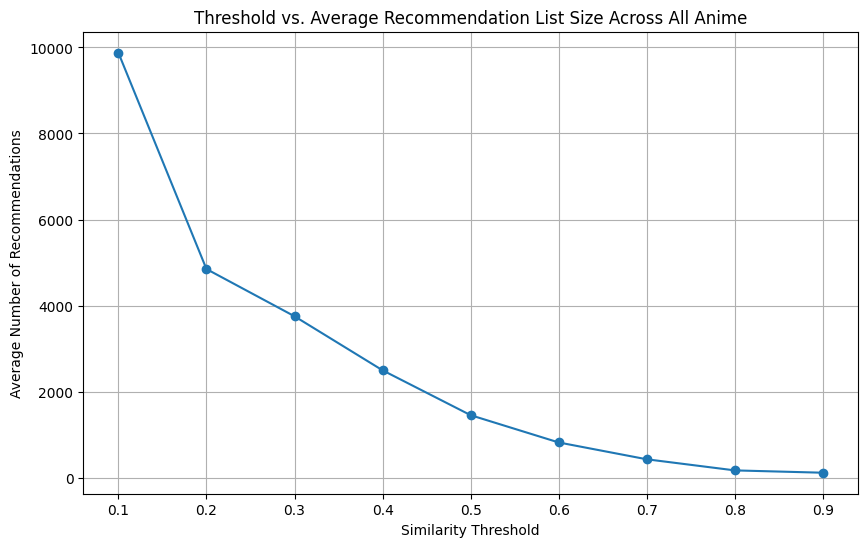

In [37]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

# Normalize the combined feature matrix X before computing cosine similarity
# L2 normalization ensures that the dot product (cosine similarity) is not dominated by feature magnitude.
X_normalized = normalize(X, norm='l2')

# Compute Cosine Similarity Matrix:
# This matrix will have dimensions (num_animes, num_animes), where each cell (i, j)
# represents the cosine similarity between anime i and anime j.
cosine_sim = cosine_similarity(X_normalized, X_normalized)
print(f"\nShape of Cosine Similarity Matrix: {cosine_sim.shape}")

# Design a function to recommend anime based on cosine similarity:
def recommend_anime(target_anime_name, df, cosine_sim_matrix, threshold=None, top_n=10):
    """
    Recommends similar anime based on cosine similarity.

    Parameters:
    - target_anime_name: str, name of the target anime.
    - df: DataFrame containing the anime data (must have 'name' column).
    - cosine_sim_matrix: 2D numpy array, the precomputed pairwise cosine similarity matrix.
    - threshold: float (0-1) or None. If set, only returns items with similarity >= threshold.
    - top_n: int, maximum number of recommendations to return.

    Returns:
    - DataFrame with recommended anime titles and similarity scores.
    """
    # Find the index of the target anime in the DataFrame
    idx_list = df.index[df['name'] == target_anime_name].tolist()
    if not idx_list:
        raise ValueError(f"Anime '{target_anime_name}' not found in the dataset. Please check the name.")
    target_anime_idx = idx_list[0]

    # Get similarity scores for all other anime with the target anime
    sim_scores = list(enumerate(cosine_sim_matrix[target_anime_idx]))

    # Remove the target anime itself from the recommendations (similarity to itself is 1.0)
    sim_scores = [(i, score) for i, score in sim_scores if i != target_anime_idx]

    # Sort the anime by similarity scores in descending order
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Apply threshold if specified
    if threshold is not None:
        sim_scores = [(i, score) for i, score in sim_scores if score >= threshold]

    # Limit to the top_n recommendations
    sim_scores = sim_scores[:top_n]

    # Retrieve the recommended anime names and their similarity scores
    anime_indices = [i for i, _ in sim_scores]
    recommended_df = df.iloc[anime_indices][['name']].copy()
    recommended_df['similarity'] = [score for _, score in sim_scores]
    recommended_df = recommended_df.reset_index(drop=True)
    recommended_df.rename(columns={'name': 'title'}, inplace=True) # Rename for consistent output

    return recommended_df

# Given a target anime, recommend a list of similar anime:
# Using 'Naruto' as a target, as identified from previous execution. If not found, tries 'Death Note' then 'Steins;Gate'.
target_anime_to_recommend = "Naruto"
if target_anime_to_recommend not in df['name'].values:
    print(f"'{target_anime_to_recommend}' not found. Trying 'Death Note'.")
    target_anime_to_recommend = "Death Note"
if target_anime_to_recommend not in df['name'].values:
    print(f"'{target_anime_to_recommend}' not found. Trying 'Steins;Gate'.")
    target_anime_to_recommend = "Steins;Gate"

print(f"\nGenerating recommendations for: {target_anime_to_recommend}")
recommendations = recommend_anime(target_anime_to_recommend, df, cosine_sim, threshold=0.7, top_n=5)
print(f"Top 5 recommendations for '{target_anime_to_recommend}' (threshold=0.7):\n")
display(recommendations)

# Experiment with different threshold values for similarity scores:
print(f"\nExperimenting with different thresholds for '{target_anime_to_recommend}':")
for th in [0.5, 0.7, 0.9]:
    recs_at_threshold = recommend_anime(target_anime_to_recommend, df, cosine_sim, threshold=th, top_n=10)
    print(f"\nThreshold = {th} \u2192 {len(recs_at_threshold)} recommendations:")
    display(recs_at_threshold[['title', 'similarity']])

# Visualize the impact of thresholds on the average number of recommendations
thresholds = np.arange(0.1, 1.0, 0.1)
avg_rec_counts = []
for th in thresholds:
    counts = []
    for idx in range(len(df)):
        sim = cosine_sim[idx]
        sim_without_self = np.delete(sim, idx) # Exclude similarity to self
        count = np.sum(sim_without_self >= th)
        counts.append(count)
    avg_rec_counts.append(np.mean(counts))

plt.figure(figsize=(10, 6))
plt.plot(thresholds, avg_rec_counts, marker='o')
plt.xlabel('Similarity Threshold')
plt.ylabel('Average Number of Recommendations')
plt.title('Threshold vs. Average Recommendation List Size Across All Anime')
plt.grid(True)
plt.show()


Evaluating recommendation quality for 'Naruto':

Recommendations for 'Naruto':


,title,similarity
0,Naruto: Shippuuden,0.999980
1,Boruto: Naruto the Movie - Naruto ga Hokage ni...,0.999980
2,Boruto: Naruto the Movie,0.999944
3,Naruto x UT,0.999938
4,Naruto: Shippuuden Movie 4 - The Lost Tower,0.999907
5,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,0.999886
6,Naruto Shippuuden: Sunny Side Battle,0.999639
7,Naruto Soyokazeden Movie: Naruto to Mashin to ...,0.999413
8,Katekyo Hitman Reborn!,0.904931
9,Kyutai Panic Adventure!,0.895984


Average Similarity Score: 0.9800
Target Anime Genres: Action, Comedy, Martial Arts, Shounen, Super Power
Recommended Genres: Action, Comedy, Martial Arts, Shounen, Super Power


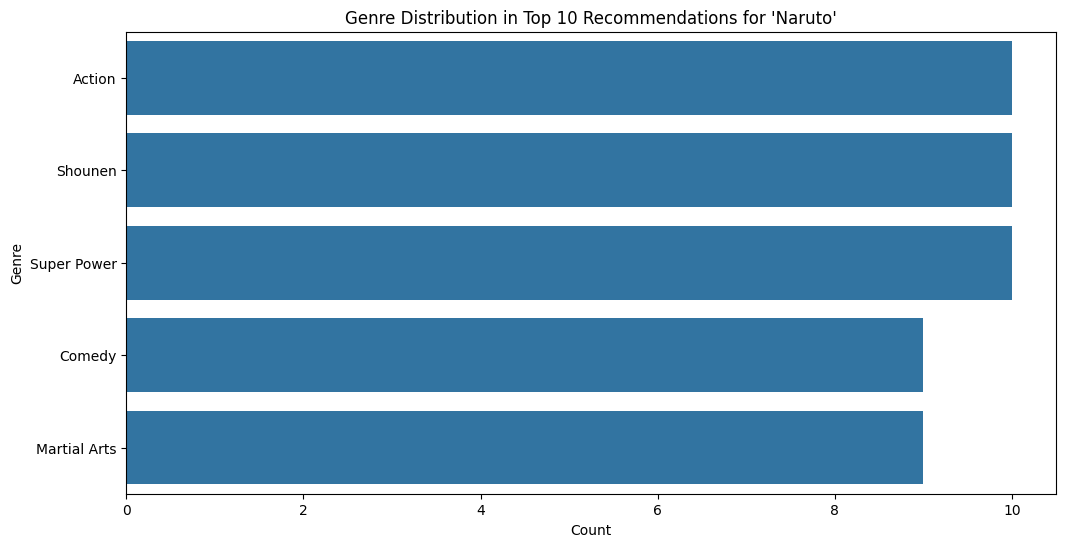


### Areas for Improvement:

1.  **Feature Engineering**: Incorporate more features like 'episodes', 'type', 'members', or even create 'popularity' from 'members'. Textual features from plot summaries (if available) could also be powerful.
2.  **User Data**: If user ratings were available (beyond average ratings), a truly collaborative filtering approach (user-based or item-based CF on user-item matrix) could be built.
3.  **Hybrid Approaches**: Combine content-based (like this) with collaborative filtering or even incorporate external data.
4.  **Performance Metrics**: Introduce metrics like precision, recall, F1-score, or Mean Average Precision (MAP) if ground truth (e.g., actual user preferences) is available.
5.  **Cold Start**: Address cold start problems for new anime (no ratings) or new users (no history).


In [20]:
# Function to get recommendations and calculate metrics
def get_recommendations_and_evaluation_metrics(target_anime_name, df, cosine_sim_matrix, threshold=0.7, top_n=10):
    try:
        recs_df = recommend_anime(target_anime_name, df, cosine_sim_matrix, threshold, top_n)
        if recs_df.empty:
            print(f"No recommendations found for '{target_anime_name}' with threshold {threshold}.")
            return None, None, None, None

        avg_similarity = recs_df['similarity'].mean()

        # Get genres of recommended anime
        # Ensure 'genre_list' is available from Feature Extraction
        rec_indices = [df[df['name'] == title].index[0] for title in recs_df['title']]
        recommended_genres = df.loc[rec_indices, 'genre_list'].explode().dropna().unique()

        # Get genres of the target anime
        target_genres_list = df[df['name'] == target_anime_name]['genre_list'].iloc[0]

        return recs_df, avg_similarity, recommended_genres, target_genres_list
    except ValueError as e:
        print(f"Error during evaluation for '{target_anime_name}': {e}")
        return None, None, None, None


# Evaluate for the target anime used in the recommendation section
print(f"\nEvaluating recommendation quality for '{target_anime_to_recommend}':\n")

eval_recs_df, avg_sim_score, rec_genres_array, target_genres_array = \
    get_recommendations_and_evaluation_metrics(target_anime_to_recommend, df, cosine_sim, threshold=0.7, top_n=10)

if eval_recs_df is not None:
    print(f"Recommendations for '{target_anime_to_recommend}':")
    display(eval_recs_df)
    print(f"Average Similarity Score: {avg_sim_score:.4f}")
    print(f"Target Anime Genres: {', '.join(target_genres_array)}")
    print(f"Recommended Genres: {', '.join(rec_genres_array)}")

    # Visualize Genre Distribution of Recommendations
    if not eval_recs_df.empty:
        recommended_titles_for_plot = eval_recs_df['title'].tolist()
        recommended_df_for_plot = df[df['name'].isin(recommended_titles_for_plot)]

        all_recommended_genres_for_plot = recommended_df_for_plot['genre_list'].explode().dropna()

        if not all_recommended_genres_for_plot.empty:
            plt.figure(figsize=(12, 6))
            sns.countplot(y=all_recommended_genres_for_plot, order=all_recommended_genres_for_plot.value_counts().index)
            plt.title(f"Genre Distribution in Top 10 Recommendations for '{target_anime_to_recommend}'")
            plt.xlabel("Count")
            plt.ylabel("Genre")
            plt.show()
        else:
            print(f"No genres found for recommendations for '{target_anime_to_recommend}' to visualize.")
    else:
        print("No recommendations to visualize genre distribution for.")
else:
    print(f"Could not evaluate recommendations for '{target_anime_to_recommend}'.")

print("\n### Areas for Improvement:\n")
print("1.  **Feature Engineering**: Incorporate more features like 'episodes', 'type', 'members', or even create 'popularity' from 'members'. Textual features from plot summaries (if available) could also be powerful.")
print("2.  **User Data**: If user ratings were available (beyond average ratings), a truly collaborative filtering approach (user-based or item-based CF on user-item matrix) could be built.")
print("3.  **Hybrid Approaches**: Combine content-based (like this) with collaborative filtering or even incorporate external data.")
print("4.  **Performance Metrics**: Introduce metrics like precision, recall, F1-score, or Mean Average Precision (MAP) if ground truth (e.g., actual user preferences) is available.")
print("5.  **Cold Start**: Address cold start problems for new anime (no ratings) or new users (no history).")

## 3. Recommendation System

This section designs the recommendation function based on cosine similarity, computes the similarity matrix, and experiments with different threshold values.


Shape of Cosine Similarity Matrix: (12294, 12294)

Generating recommendations for: Naruto
Top 5 recommendations for 'Naruto' (threshold=0.7):



,title,similarity
0,Naruto: Shippuuden,0.999980
1,Boruto: Naruto the Movie - Naruto ga Hokage ni...,0.999980
2,Boruto: Naruto the Movie,0.999944
3,Naruto x UT,0.999938
4,Naruto: Shippuuden Movie 4 - The Lost Tower,0.999907



Experimenting with different thresholds for 'Naruto':

Threshold = 0.5 → 10 recommendations:


,title,similarity
0,Naruto: Shippuuden,0.999980
1,Boruto: Naruto the Movie - Naruto ga Hokage ni...,0.999980
2,Boruto: Naruto the Movie,0.999944
3,Naruto x UT,0.999938
4,Naruto: Shippuuden Movie 4 - The Lost Tower,0.999907
5,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,0.999886
6,Naruto Shippuuden: Sunny Side Battle,0.999639
7,Naruto Soyokazeden Movie: Naruto to Mashin to ...,0.999413
8,Katekyo Hitman Reborn!,0.904931
9,Kyutai Panic Adventure!,0.895984



Threshold = 0.7 → 10 recommendations:


,title,similarity
0,Naruto: Shippuuden,0.999980
1,Boruto: Naruto the Movie - Naruto ga Hokage ni...,0.999980
2,Boruto: Naruto the Movie,0.999944
3,Naruto x UT,0.999938
4,Naruto: Shippuuden Movie 4 - The Lost Tower,0.999907
5,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,0.999886
6,Naruto Shippuuden: Sunny Side Battle,0.999639
7,Naruto Soyokazeden Movie: Naruto to Mashin to ...,0.999413
8,Katekyo Hitman Reborn!,0.904931
9,Kyutai Panic Adventure!,0.895984



Threshold = 0.9 → 9 recommendations:


,title,similarity
0,Naruto: Shippuuden,0.999980
1,Boruto: Naruto the Movie - Naruto ga Hokage ni...,0.999980
2,Boruto: Naruto the Movie,0.999944
3,Naruto x UT,0.999938
4,Naruto: Shippuuden Movie 4 - The Lost Tower,0.999907
5,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,0.999886
6,Naruto Shippuuden: Sunny Side Battle,0.999639
7,Naruto Soyokazeden Movie: Naruto to Mashin to ...,0.999413
8,Katekyo Hitman Reborn!,0.904931


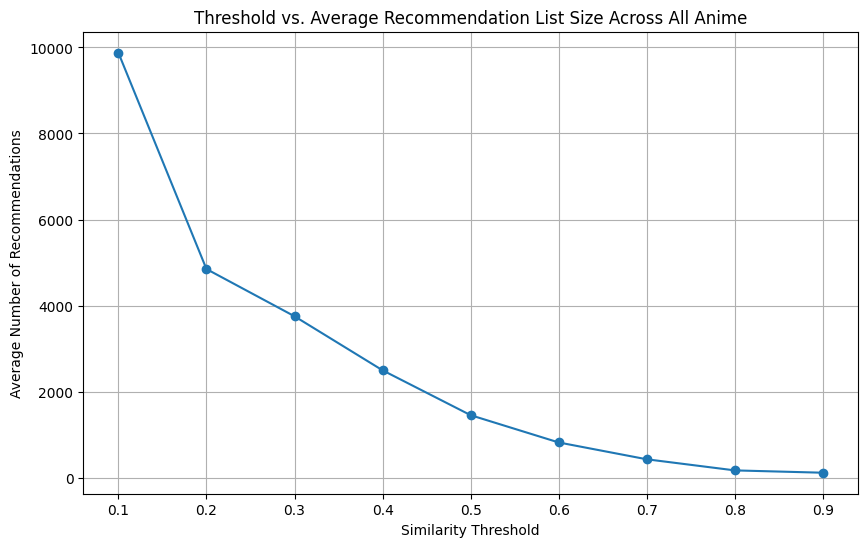

In [38]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

# Normalize the combined feature matrix X before computing cosine similarity
# L2 normalization ensures that the dot product (cosine similarity) is not dominated by feature magnitude.
X_normalized = normalize(X, norm='l2')

# Compute Cosine Similarity Matrix:
# This matrix will have dimensions (num_animes, num_animes), where each cell (i, j)
# represents the cosine similarity between anime i and anime j.
cosine_sim = cosine_similarity(X_normalized, X_normalized)
print(f"\nShape of Cosine Similarity Matrix: {cosine_sim.shape}")

# Design a function to recommend anime based on cosine similarity:
def recommend_anime(target_anime_name, df, cosine_sim_matrix, threshold=None, top_n=10):
    """
    Recommends similar anime based on cosine similarity.

    Parameters:
    - target_anime_name: str, name of the target anime.
    - df: DataFrame containing the anime data (must have 'name' column).
    - cosine_sim_matrix: 2D numpy array, the precomputed pairwise cosine similarity matrix.
    - threshold: float (0-1) or None. If set, only returns items with similarity >= threshold.
    - top_n: int, maximum number of recommendations to return.

    Returns:
    - DataFrame with recommended anime titles and similarity scores.
    """
    # Find the index of the target anime in the DataFrame
    idx_list = df.index[df['name'] == target_anime_name].tolist()
    if not idx_list:
        raise ValueError(f"Anime '{target_anime_name}' not found in the dataset. Please check the name.")
    target_anime_idx = idx_list[0]

    # Get similarity scores for all other anime with the target anime
    sim_scores = list(enumerate(cosine_sim_matrix[target_anime_idx]))

    # Remove the target anime itself from the recommendations (similarity to itself is 1.0)
    sim_scores = [(i, score) for i, score in sim_scores if i != target_anime_idx]

    # Sort the anime by similarity scores in descending order
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Apply threshold if specified
    if threshold is not None:
        sim_scores = [(i, score) for i, score in sim_scores if score >= threshold]

    # Limit to the top_n recommendations
    sim_scores = sim_scores[:top_n]

    # Retrieve the recommended anime names and their similarity scores
    anime_indices = [i for i, _ in sim_scores]
    recommended_df = df.iloc[anime_indices][['name']].copy()
    recommended_df['similarity'] = [score for _, score in sim_scores]
    recommended_df = recommended_df.reset_index(drop=True)
    recommended_df.rename(columns={'name': 'title'}, inplace=True) # Rename for consistent output

    return recommended_df

# Given a target anime, recommend a list of similar anime:
# Using 'Naruto' as a target, as identified from previous execution. If not found, tries 'Death Note' then 'Steins;Gate'.
target_anime_to_recommend = "Naruto"
if target_anime_to_recommend not in df['name'].values:
    print(f"'{target_anime_to_recommend}' not found. Trying 'Death Note'.")
    target_anime_to_recommend = "Death Note"
if target_anime_to_recommend not in df['name'].values:
    print(f"'{target_anime_to_recommend}' not found. Trying 'Steins;Gate'.")
    target_anime_to_recommend = "Steins;Gate"

print(f"\nGenerating recommendations for: {target_anime_to_recommend}")
recommendations = recommend_anime(target_anime_to_recommend, df, cosine_sim, threshold=0.7, top_n=5)
print(f"Top 5 recommendations for '{target_anime_to_recommend}' (threshold=0.7):\n")
display(recommendations)

# Experiment with different threshold values for similarity scores:
print(f"\nExperimenting with different thresholds for '{target_anime_to_recommend}':")
for th in [0.5, 0.7, 0.9]:
    recs_at_threshold = recommend_anime(target_anime_to_recommend, df, cosine_sim, threshold=th, top_n=10)
    print(f"\nThreshold = {th} \u2192 {len(recs_at_threshold)} recommendations:")
    display(recs_at_threshold[['title', 'similarity']])

# Visualize the impact of thresholds on the average number of recommendations
thresholds = np.arange(0.1, 1.0, 0.1)
avg_rec_counts = []
for th in thresholds:
    counts = []
    for idx in range(len(df)):
        sim = cosine_sim[idx]
        sim_without_self = np.delete(sim, idx) # Exclude similarity to self
        count = np.sum(sim_without_self >= th)
        counts.append(count)
    avg_rec_counts.append(np.mean(counts))

plt.figure(figsize=(10, 6))
plt.plot(thresholds, avg_rec_counts, marker='o')
plt.xlabel('Similarity Threshold')
plt.ylabel('Average Number of Recommendations')
plt.title('Threshold vs. Average Recommendation List Size Across All Anime')
plt.grid(True)
plt.show()

## 4. Analyze Performance and Identify Areas of Improvement

This section focuses on evaluating the quality of the recommendations using metrics like average similarity and genre diversity, and visualizing genre distribution.


Evaluating recommendation quality for 'Naruto':

Recommendations for 'Naruto':


,title,similarity
0,Naruto: Shippuuden,0.999980
1,Boruto: Naruto the Movie - Naruto ga Hokage ni...,0.999980
2,Boruto: Naruto the Movie,0.999944
3,Naruto x UT,0.999938
4,Naruto: Shippuuden Movie 4 - The Lost Tower,0.999907
5,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,0.999886
6,Naruto Shippuuden: Sunny Side Battle,0.999639
7,Naruto Soyokazeden Movie: Naruto to Mashin to ...,0.999413
8,Katekyo Hitman Reborn!,0.904931
9,Kyutai Panic Adventure!,0.895984


Average Similarity Score: 0.9800
Target Anime Genres: Action, Comedy, Martial Arts, Shounen, Super Power
Recommended Genres: Action, Comedy, Martial Arts, Shounen, Super Power


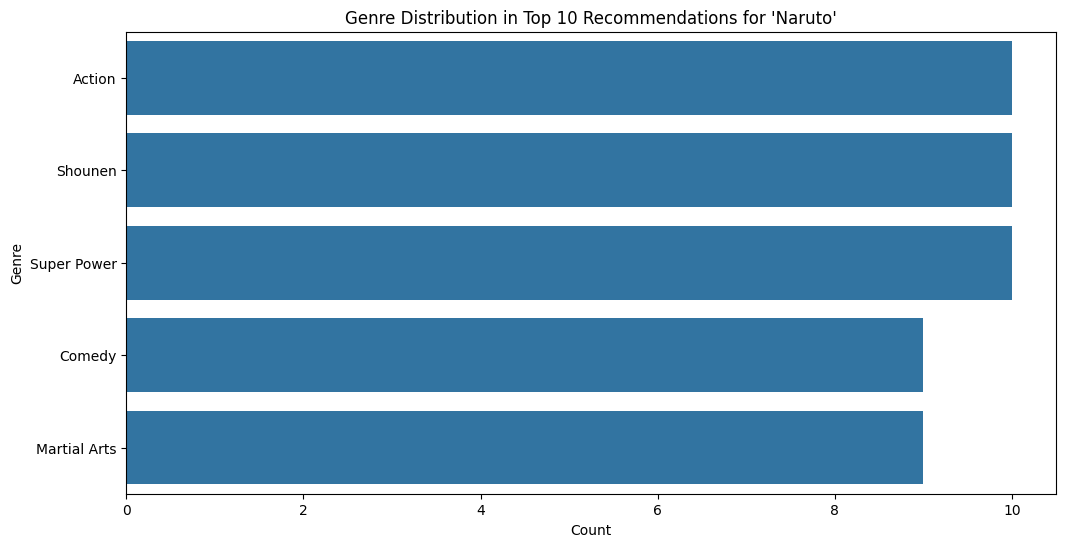


### Areas for Improvement:

1.  **Feature Engineering**: Incorporate more features like 'episodes', 'type', 'members', or even create 'popularity' from 'members'. Textual features from plot summaries (if available) could also be powerful.
2.  **User Data**: If user ratings were available (beyond average ratings), a truly collaborative filtering approach (user-based or item-based CF on user-item matrix) could be built.
3.  **Hybrid Approaches**: Combine content-based (like this) with collaborative filtering or even incorporate external data.
4.  **Performance Metrics**: Introduce metrics like precision, recall, F1-score, or Mean Average Precision (MAP) if ground truth (e.g., actual user preferences) is available.
5.  **Cold Start**: Address cold start problems for new anime (no ratings) or new users (no history).


In [14]:
# Function to get recommendations and calculate metrics
def get_recommendations_and_evaluation_metrics(target_anime_name, df, cosine_sim_matrix, threshold=0.7, top_n=10):
    try:
        recs_df = recommend_anime(target_anime_name, df, cosine_sim_matrix, threshold, top_n)
        if recs_df.empty:
            print(f"No recommendations found for '{target_anime_name}' with threshold {threshold}.")
            return None, None, None, None

        avg_similarity = recs_df['similarity'].mean()

        # Get genres of recommended anime
        # Ensure 'genre_list' is available from Feature Extraction
        rec_indices = [df[df['name'] == title].index[0] for title in recs_df['title']]
        recommended_genres = df.loc[rec_indices, 'genre_list'].explode().dropna().unique()

        # Get genres of the target anime
        target_genres_list = df[df['name'] == target_anime_name]['genre_list'].iloc[0]

        return recs_df, avg_similarity, recommended_genres, target_genres_list
    except ValueError as e:
        print(f"Error during evaluation for '{target_anime_name}': {e}")
        return None, None, None, None


# Evaluate for the target anime used in the recommendation section
print(f"\nEvaluating recommendation quality for '{target_anime_to_recommend}':\n")

eval_recs_df, avg_sim_score, rec_genres_array, target_genres_array = \
    get_recommendations_and_evaluation_metrics(target_anime_to_recommend, df, cosine_sim, threshold=0.7, top_n=10)

if eval_recs_df is not None:
    print(f"Recommendations for '{target_anime_to_recommend}':")
    display(eval_recs_df)
    print(f"Average Similarity Score: {avg_sim_score:.4f}")
    print(f"Target Anime Genres: {', '.join(target_genres_array)}")
    print(f"Recommended Genres: {', '.join(rec_genres_array)}")

    # Visualize Genre Distribution of Recommendations
    if not eval_recs_df.empty:
        recommended_titles_for_plot = eval_recs_df['title'].tolist()
        recommended_df_for_plot = df[df['name'].isin(recommended_titles_for_plot)]

        all_recommended_genres_for_plot = recommended_df_for_plot['genre_list'].explode().dropna()

        if not all_recommended_genres_for_plot.empty:
            plt.figure(figsize=(12, 6))
            sns.countplot(y=all_recommended_genres_for_plot, order=all_recommended_genres_for_plot.value_counts().index)
            plt.title(f"Genre Distribution in Top 10 Recommendations for '{target_anime_to_recommend}'")
            plt.xlabel("Count")
            plt.ylabel("Genre")
            plt.show()
        else:
            print(f"No genres found for recommendations for '{target_anime_to_recommend}' to visualize.")
    else:
        print("No recommendations to visualize genre distribution for.")
else:
    print(f"Could not evaluate recommendations for '{target_anime_to_recommend}'.")

print("\n### Areas for Improvement:\n")
print("1.  **Feature Engineering**: Incorporate more features like 'episodes', 'type', 'members', or even create 'popularity' from 'members'. Textual features from plot summaries (if available) could also be powerful.")
print("2.  **User Data**: If user ratings were available (beyond average ratings), a truly collaborative filtering approach (user-based or item-based CF on user-item matrix) could be built.")
print("3.  **Hybrid Approaches**: Combine content-based (like this) with collaborative filtering or even incorporate external data.")
print("4.  **Performance Metrics**: Introduce metrics like precision, recall, F1-score, or Mean Average Precision (MAP) if ground truth (e.g., actual user preferences) is available.")
print("5.  **Cold Start**: Address cold start problems for new anime (no ratings) or new users (no history).")

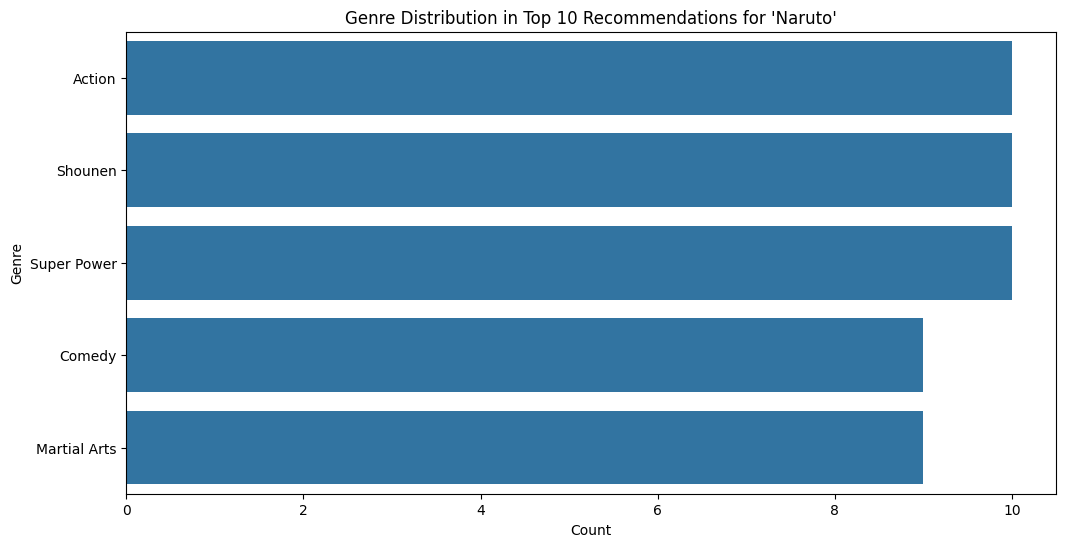

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get all genres from the recommended list
if recs_df is not None:
    # Get original genre strings for recommended titles
    recommended_titles = recs_df['title'].tolist()
    recommended_df = df[df['name'].isin(recommended_titles)]

    all_recommended_genres = recommended_df['genre_list'].explode().dropna()

    if not all_recommended_genres.empty:
        plt.figure(figsize=(12, 6))
        sns.countplot(y=all_recommended_genres, order=all_recommended_genres.value_counts().index)
        plt.title(f"Genre Distribution in Top 10 Recommendations for '{target_anime}'")
        plt.xlabel("Count")
        plt.ylabel("Genre")
        plt.show()
    else:
        print(f"No genres found for recommendations for '{target_anime}'.")
else:
    print(f"Cannot visualize genre distribution as no recommendations were generated for '{target_anime}'.")

Interview Questions:
--

### 1. Difference Between User-Based and Item-Based Collaborative Filtering

Both are **memory-based collaborative filtering** methods that rely on user–item interaction data (e.g., ratings, clicks, purchases) to make recommendations. The core difference lies in **what we consider the “neighborhood.”**

| Aspect | User-Based Collaborative Filtering | Item-Based Collaborative Filtering |
|--------|------------------------------------|-------------------------------------|
| **Core idea** | “Users who liked the same items as you also liked…” | “Items that are liked by the same users are similar…” |
| **Neighborhood** | Find similar *users* based on their rating patterns. | Find similar *items* based on the ratings they have received. |
| **Recommendation logic** | 1. Identify a group of users with the most similar taste to the target user.<br>2. Recommend items those similar users liked but the target user hasn’t seen yet. | 1. For an item the target user already likes, find other items that correlate highly in ratings across all users.<br>2. Recommend those similar items. |
| **Similarity computation** | Compare rows (user vectors) of the user–item rating matrix. | Compare columns (item vectors) of the user–item rating matrix. |
| **Scalability** | Works well when the number of users is smaller than the number of items. Computation grows with the number of users. | Usually more scalable in practice because item–item similarities tend to be more stable over time and can be precomputed. Amazon famously uses item-based CF. |
| **Dynamic behaviour** | User similarity can change rapidly as user profiles update; needs frequent recomputation. | Item similarities are relatively static; precomputed models can be updated less frequently. |
| **Sparsity handling** | May struggle with new users (cold start) because they have few ratings to find similar users. | Still effective for new users if they rate a few popular items, because those items already have stable similarity profiles. |

**Key takeaway:** User-based CF finds like-minded *people*, while item-based CF finds substitutable *items*. In practice, item-based CF often produces more interpretable and stable recommendations, especially in large-scale e‑commerce.

---

### 2. What is Collaborative Filtering and How Does It Work?

**Collaborative filtering (CF)** is a recommendation technique that predicts a user’s preferences by collecting taste information from many users. The central assumption is: *if two users agreed in the past, they will agree in the future.*

**How it works in general:**

1. **Data collection**  
   CF needs a user–item interaction matrix. Each cell holds a signal like a rating (explicit feedback) or a click/view/purchase (implicit feedback). The matrix is typically very sparse—most users interact with only a tiny fraction of all items.

2. **Finding neighbors / learning latent factors**  
   There are two main families:

   - **Memory-based CF** (neighborhood methods):  
     - Compute similarity between users (user-based) or items (item-based) using metrics like Pearson correlation or cosine similarity on the rating vectors.  
     - For a target user, aggregate ratings from the most similar users to predict unseen items, or recommend items most similar to those the user already likes.

   - **Model-based CF** (latent factor models):  
     - Decompose the sparse rating matrix into low‑rank representations using matrix factorization (e.g., SVD, alternating least squares).  
     - Each user and each item gets a dense vector (latent factors) of length \(k\). The predicted rating for user \(u\) on item \(i\) is the dot product \(\mathbf{p}_u^T \mathbf{q}_i\).  
     - Models are trained by minimizing reconstruction error on observed ratings, often with regularization to avoid overfitting.

3. **Prediction generation**  
   For memory-based methods, missing ratings are predicted as a weighted average of neighbor ratings. For model-based methods, missing entries are filled via the dot product. The items with the highest predicted scores are recommended.

4. **Strengths and challenges**  
   - **Strengths:** Requires no item metadata; purely based on behavioral patterns. Can discover surprising, cross‑genre recommendations.  
   - **Challenges:**  
     - **Cold start:** New users/items have no interaction history.  
     - **Sparsity:** The user–item matrix is very empty, making similarity calculations unreliable.  
     - **Scalability:** Neighborhood‑based CF can be compute‑heavy for millions of users or items.  
     - **Popularity bias:** Tends to recommend popular items; niche items may never get suggested.

**In short:** Collaborative filtering is the engine behind “people who bought this also bought” and “you might also like.” It leverages the collective behavior of the user base to personalize recommendations without needing to understand the items themselves.